In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Cell 2 - Generate Dataset
np.random.seed(42)
n = 1000

data = {
    'Age': np.random.randint(22, 65, n),
    'Income': np.random.randint(20000, 150000, n),
    'Loan_Amount': np.random.randint(1000, 50000, n),
    'Credit_Utilization': np.random.uniform(0.1, 0.9, n),
    'Num_Late_Payments': np.random.randint(0, 10, n),
    'Num_Active_Loans': np.random.randint(0, 5, n),
    'Payment_History': np.random.randint(50, 100, n),
}

def assign_credit_score(row):
    if row['Income'] > 100000 and row['Num_Late_Payments'] < 2:
        return 'Good'
    elif row['Income'] < 40000 or row['Num_Late_Payments'] > 6:
        return 'Poor'
    else:
        return 'Average'

df = pd.DataFrame(data)
df['Credit_Score'] = df.apply(assign_credit_score, axis=1)
df.to_csv('credit_score_data.csv', index=False)
print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   Age  Income  Loan_Amount  Credit_Utilization  Num_Late_Payments  \
0   60  122916         7154            0.760105                  4   
1   50  132250        22804            0.516237                  5   
2   36  136553        42688            0.398770                  0   
3   64   63872        21581            0.197901                  0   
4   29   66197        31087            0.688404                  8   

   Num_Active_Loans  Payment_History Credit_Score  
0                 4               57      Average  
1                 4               52      Average  
2                 0               97         Good  
3                 3               95      Average  
4                 4               58         Poor  


Dataset Shape: (1000, 8)
Credit_Score
Average    529
Poor       395
Good        76
Name: count, dtype: int64


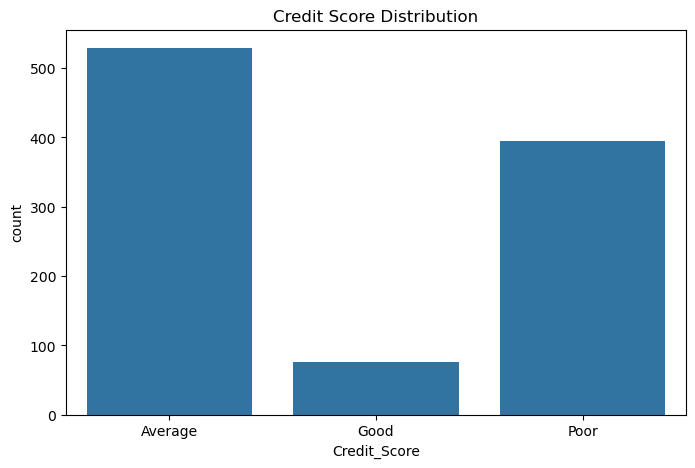

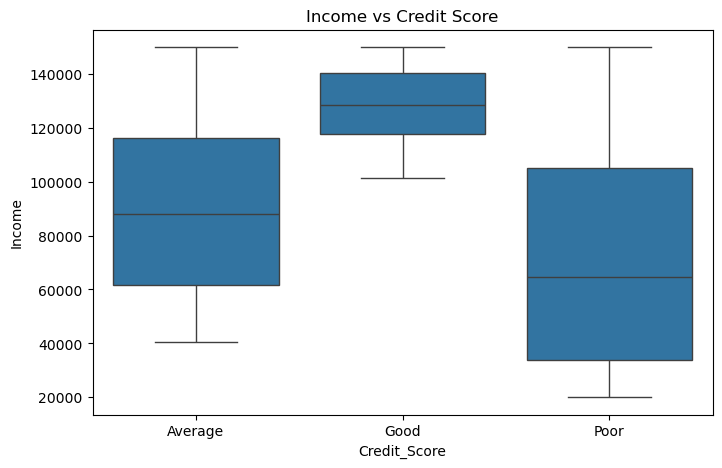

EDA done!


In [10]:
# Cell 3 - EDA
print("Dataset Shape:", df.shape)
print(df['Credit_Score'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='Credit_Score', data=df)
plt.title('Credit Score Distribution')
plt.savefig('credit_score_distribution.png')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Credit_Score', y='Income', data=df)
plt.title('Income vs Credit Score')
plt.savefig('income_vs_credit_score.png')
plt.show()

print("EDA done!")

In [11]:
# Cell 4 - Train the Model
le = LabelEncoder()
df['Credit_Score_Encoded'] = le.fit_transform(df['Credit_Score'])

features = ['Age', 'Income', 'Loan_Amount', 'Credit_Utilization', 
            'Num_Late_Payments', 'Num_Active_Loans', 'Payment_History']

X = df[features]
y = df['Credit_Score_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial')
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training Score:", model.score(X_train, y_train))

Model trained successfully!
Training Score: 0.77375


Accuracy Score: 0.78

Classification Report:
              precision    recall  f1-score   support

     Average       0.81      0.78      0.79       108
        Good       0.64      0.37      0.47        19
        Poor       0.76      0.89      0.82        73

    accuracy                           0.78       200
   macro avg       0.74      0.68      0.69       200
weighted avg       0.78      0.78      0.77       200



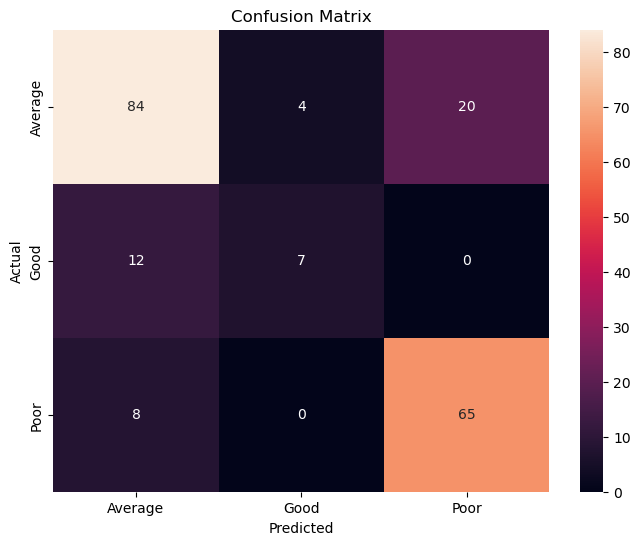

In [12]:
# Cell 5 - Evaluate the Model
y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

In [13]:
# Cell 6 - Save the Model
joblib.dump(model, 'credit_score_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model saved successfully as credit_score_model.pkl!")

Model saved successfully as credit_score_model.pkl!


In [14]:
# Cell 7 - Test Prediction on New Customer
new_customer = pd.DataFrame({
    'Age': [35],
    'Income': [75000],
    'Loan_Amount': [15000],
    'Credit_Utilization': [0.4],
    'Num_Late_Payments': [2],
    'Num_Active_Loans': [2],
    'Payment_History': [80]
})

prediction = model.predict(new_customer)
predicted_label = le.inverse_transform(prediction)

print("Customer Credit Score Prediction:", predicted_label[0])
print("\nProject Complete!")

Customer Credit Score Prediction: Average

Project Complete!
